# Определение возраста покупателя по фотографии

**Описание проекта**   
Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:  
- анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;  
- контролировать добросовестность кассиров при продаже алкоголя.

**Цель проекта:**   
Построить модель, которая по фотографии определит приблизительный возраст человека. Цель - ошибка MAE должна быть менее 8 (лет)

**Содержание:**  
<div class="toc"><ul class="toc-item"><li><span><a href="#анализ" data-toc-modified-id="анализ-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li><li><span><a href="#обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение модели</a></span></li><li><span><a href="#анализ модели" data-toc-modified-id="анализ модели-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Анализ обученной модели</a></span></li></li></ul></div>

**Описание данных:**   
Датасет с фотографиями и возрастом пользователей. Около 8000 фотографий

**Общий вывод:**   
По результатам обучения нейросети (ResNet50) и проверки на валидационной выборке ошибка MAE составляет примерно 6.2 лет. Задача выполнена


<a id="анализ"></a> 
## Исследовательский анализ данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
labels.head(12)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39


Посмотрим на статистические цифры по данному датасету и возрасту

In [3]:
print(f"размер датасета:", labels.shape, '\n')
print(f"пропуски:\n" + labels.isna().sum().to_string(), '\n')
print(f"минимальный возраст:", labels['real_age'].min())
print(f"максимальный возраст:",labels['real_age'].max())
print(f"средний возраст:",labels['real_age'].mean())
print(f"медианный возраст:",labels['real_age'].median())
print(f"мода:",labels['real_age'].mode()[0])

размер датасета: (7591, 2) 

пропуски:
file_name    0
real_age     0 

минимальный возраст: 1
максимальный возраст: 100
средний возраст: 31.20115926755368
медианный возраст: 29.0
мода: 30


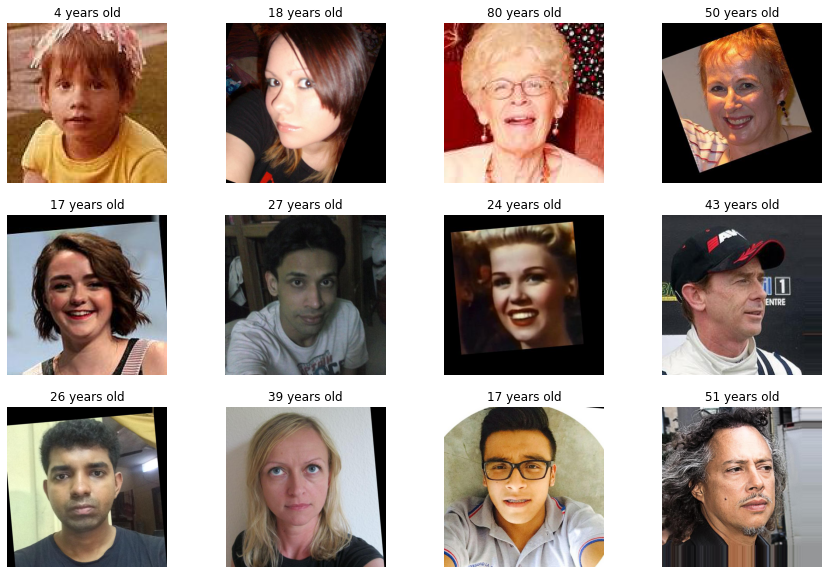

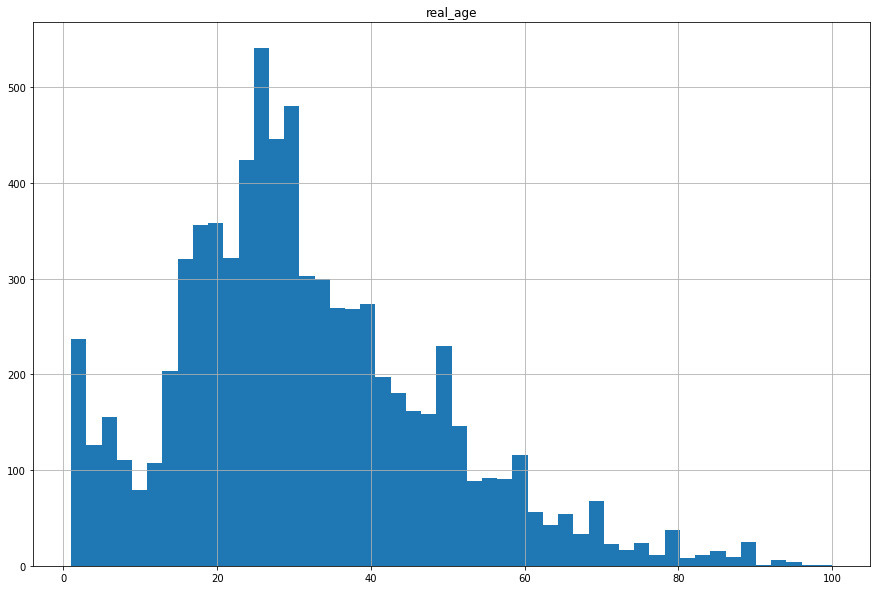

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(15,10))

for i in range(12):
    file_name = labels.loc[i, 'file_name']
    age = labels.loc[i, 'real_age']
    img_path = '/datasets/faces/final_files/' + file_name
    img = Image.open(img_path)
    row = i // 4
    col = i % 4
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"{age} years old")
    axes[row, col].axis('off')

labels.hist(bins=50, figsize=(15,10));

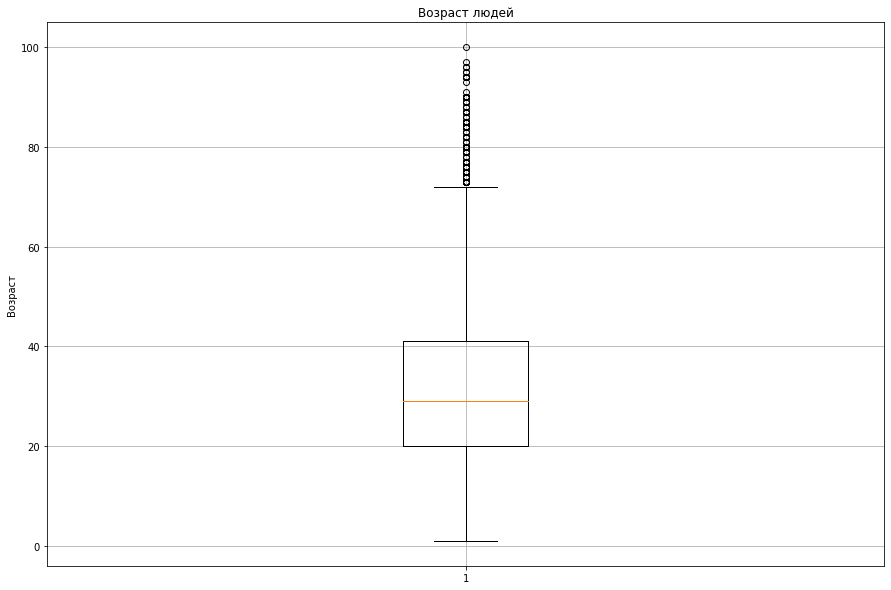

In [5]:
plt.figure(figsize=(15, 10))
plt.boxplot(labels['real_age'], vert = True)
plt.title('Возраст людей')
plt.grid(True)
plt.ylabel('Возраст');

**ВЫВОДЫ:**
- У нас датасет с 7591 названиями фотографий и их реальным возрастом. Сами фотографии лежат чуть в другой папке
- Фотографии обычный людей, где они одни в кадре. Первые 12 фотографий все цветные
- Людям на фотографии от 1 до 100 лет. Мода - 30 лет. Медиана ниже среднего (29 лет против 31.2). Что говорит о том, что у нас идет хвост пожилых людей
- Есть выбросы по возрасту

<a id="обучение"></a> 
## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet import ResNet50
import pandas as pd

def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255)
    
    train_generator = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)
    
    return train_generator


def load_test(path):
    
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255)
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)

    return test_gen_flow


def create_model(input_shape=(224, 224, 3)):

    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1))
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=15,
                steps_per_epoch=None, validation_steps=None):

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )
    
    return model

```

```

# < скопируйте результат вывода на экран сюда >
2025-12-02 10:32:16.913374: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer.so.6
2025-12-02 10:32:16.915364: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer_plugin.so.6
2025-12-02 10:32:17.816846: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcuda.so.1
2025-12-02 10:32:17.828567: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
2025-12-02 10:32:17.828622: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2025-12-02 10:32:17.828653: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-12-02 10:32:17.830883: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
2025-12-02 10:32:17.831339: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
2025-12-02 10:32:17.833770: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
2025-12-02 10:32:17.835467: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
2025-12-02 10:32:17.835524: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
2025-12-02 10:32:17.836664: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
Using TensorFlow backend.
Found 5694 validated image filenames.
Found 1897 validated image filenames.
2025-12-02 10:32:18.013361: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
2025-12-02 10:32:18.020524: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2099990000 Hz
2025-12-02 10:32:18.021226: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x155c1e30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-02 10:32:18.021255: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-12-02 10:32:18.139447: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1516ec10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-02 10:32:18.139483: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2025-12-02 10:32:18.140352: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
2025-12-02 10:32:18.140406: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2025-12-02 10:32:18.140417: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-12-02 10:32:18.140442: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
2025-12-02 10:32:18.140453: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
2025-12-02 10:32:18.140463: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
2025-12-02 10:32:18.140472: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
2025-12-02 10:32:18.140481: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
2025-12-02 10:32:18.141827: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
2025-12-02 10:32:18.141882: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2025-12-02 10:32:18.494775: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1096] Device interconnect StreamExecutor with strength 1 edge matrix:
2025-12-02 10:32:18.494835: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1102]      0 
2025-12-02 10:32:18.494844: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1115] 0:   N 
2025-12-02 10:32:18.496215: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:39] Overriding allow_growth setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-12-02 10:32:18.496262: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1241] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 10240 MB memory) -> physical GPU (device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:8b:00.0, compute capability: 7.0)
Downloading data from https://github.com/keras-team/keras-applications/releases/download/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5

    8192/94765736 [..............................] - ETA: 3s
  262144/94765736 [..............................] - ETA: 20s
 2203648/94765736 [..............................] - ETA: 4s 
 9420800/94765736 [=>............................] - ETA: 1s
10493952/94765736 [==>...........................] - ETA: 2s
19890176/94765736 [=====>........................] - ETA: 1s
20979712/94765736 [=====>........................] - ETA: 1s
24117248/94765736 [======>.......................] - ETA: 1s
25182208/94765736 [======>.......................] - ETA: 1s
28295168/94765736 [=======>......................] - ETA: 1s
29409280/94765736 [========>.....................] - ETA: 1s
31465472/94765736 [========>.....................] - ETA: 1s
39829504/94765736 [===========>..................] - ETA: 1s
41951232/94765736 [============>.................] - ETA: 1s
49848320/94765736 [==============>...............] - ETA: 0s
52436992/94765736 [===============>..............] - ETA: 0s
62029824/94765736 [==================>...........] - ETA: 0s
62922752/94765736 [==================>...........] - ETA: 0s
72024064/94765736 [=====================>........] - ETA: 0s
73408512/94765736 [======================>.......] - ETA: 0s
81559552/94765736 [========================>.....] - ETA: 0s
83894272/94765736 [=========================>....] - ETA: 0s
92913664/94765736 [============================>.] - ETA: 0s
94380032/94765736 [============================>.] - ETA: 0s
94773248/94765736 [==============================] - 1s 0us/step
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
Train for 356 steps, validate for 119 steps
Epoch 1/15
2025-12-02 10:32:30.659223: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-12-02 10:32:30.982832: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
356/356 - 48s - loss: 187.7487 - mae: 10.1080 - val_loss: 396.6118 - val_mae: 14.8595
Epoch 2/15
356/356 - 39s - loss: 63.5621 - mae: 6.1704 - val_loss: 138.6646 - val_mae: 8.7006
Epoch 3/15
356/356 - 38s - loss: 34.0733 - mae: 4.4545 - val_loss: 108.4594 - val_mae: 7.7357
Epoch 4/15
356/356 - 39s - loss: 20.8752 - mae: 3.5144 - val_loss: 72.0709 - val_mae: 6.3397
Epoch 5/15
356/356 - 39s - loss: 14.8841 - mae: 2.9522 - val_loss: 80.3734 - val_mae: 6.6452
Epoch 6/15
356/356 - 39s - loss: 12.7575 - mae: 2.6834 - val_loss: 69.1157 - val_mae: 6.2803
Epoch 7/15
356/356 - 39s - loss: 11.8404 - mae: 2.6188 - val_loss: 67.6613 - val_mae: 6.2697
Epoch 8/15
356/356 - 39s - loss: 10.3680 - mae: 2.4318 - val_loss: 67.8121 - val_mae: 6.2202
Epoch 9/15
356/356 - 39s - loss: 10.5894 - mae: 2.4342 - val_loss: 67.3661 - val_mae: 6.1841
Epoch 10/15
356/356 - 39s - loss: 10.5780 - mae: 2.4611 - val_loss: 70.3323 - val_mae: 6.2653
Epoch 11/15
356/356 - 39s - loss: 11.6347 - mae: 2.5513 - val_loss: 80.3077 - val_mae: 6.9140
Epoch 12/15
356/356 - 39s - loss: 12.0832 - mae: 2.6394 - val_loss: 70.8894 - val_mae: 6.2203
Epoch 13/15
356/356 - 39s - loss: 11.6900 - mae: 2.5372 - val_loss: 75.0411 - val_mae: 6.6595
Epoch 14/15
356/356 - 38s - loss: 9.9913 - mae: 2.3566 - val_loss: 69.2021 - val_mae: 6.0996
Epoch 15/15
356/356 - 39s - loss: 8.6955 - mae: 2.2141 - val_loss: 67.4034 - val_mae: 6.1755
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
119/119 - 10s - loss: 67.4034 - mae: 6.1755
# < длинные строки со скачиванием модели можно удалить >

```

<a id="анализ модели"></a> 
## Анализ обученной модели

1) Использовали ImageDataGenerator(rescale=1./255) для изменения масштабирования.  
2) Взяли модель ResNet50 со слоями backbone - GlobalAveragePooling2D - Dense(256) - Dense(128) - Dense(1). Один нейрон итогом для регрессии (определения возраста).  
3) Для обучения мы использовали метрику MSE, а проверяли итог по MAE.  
4) Модель обучалась 15 эпох. Почти с каждой эпохой значение MSE на тренировочной уменьшалось. Как и MAE.  
5) Переобучения нет, что важно.  
6) А значение MAE на тестовых дошло примерно до 6.1-6.4 и остановилось сильно снижаться. По условию задачи нас это устраивает.  

**То есть в среднем модель ошибается на 6.2 лет**